<a href="https://colab.research.google.com/github/VivekChaurasiya95/DecodeLabs-Internship/blob/main/Decodelabs_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project 1 : Advance EDA & Feature Engineering

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set(font_scale= 1.1)

print("Libraries Imported Successfully")



Libraries Imported Successfully


### Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Dataset for Data Analytics - Sheet1.csv to Dataset for Data Analytics - Sheet1.csv


### Read Datasets

In [3]:
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


### Datasets Shape

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1200
Columns: 14


### Dataset Information


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


### Data Types

In [6]:
df.dtypes

,0
OrderID,object
Date,object
CustomerID,object
Product,object
Quantity,int64
UnitPrice,float64
ShippingAddress,object
PaymentMethod,object
OrderStatus,object
TrackingNumber,object


### Statstical Summary

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1200.0,2.945833,1.407557,1.00,2.0000,3.000,4.000,5.00
UnitPrice,1200.0,356.412750,197.177146,11.39,186.0625,364.210,521.570,699.93
ItemsInCart,1200.0,5.485000,2.281983,1.00,4.0000,5.000,7.000,10.00
TotalPrice,1200.0,1053.968300,819.856558,11.39,410.5200,823.615,1578.475,3456.40


### Check Duplicate Records

In [8]:
duplicates = df.duplicated().sum()
print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


### Missing Values

In [9]:
missing = pd.DataFrame(df.isnull().sum(), columns=["Missing Values"])
missing["Percentage"] = round((missing["Missing Values"]/len(df))*100, 2)
missing

,Missing Values,Percentage
OrderID,0,0.00
Date,0,0.00
CustomerID,0,0.00
Product,0,0.00
Quantity,0,0.00
UnitPrice,0,0.00
ShippingAddress,0,0.00
PaymentMethod,0,0.00
OrderStatus,0,0.00
TrackingNumber,0,0.00


### Visualization

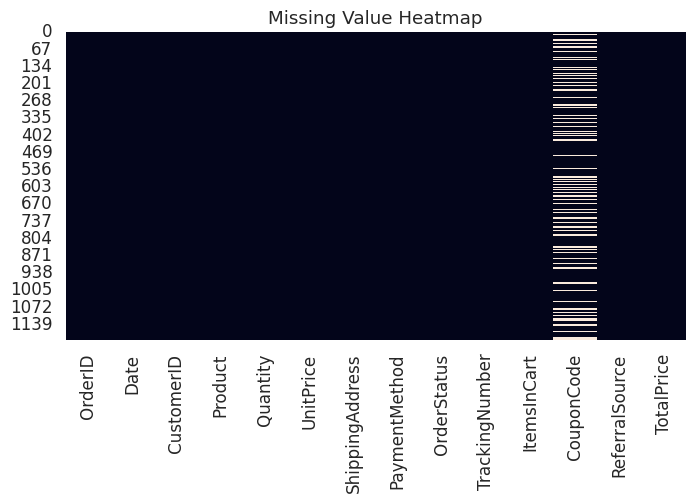

In [10]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar= False)

plt.title("Missing Value Heatmap")
plt.show()

### Unique Values

In [11]:
for col in df.columns:
  print("="*40)
  print(col)
  print(df[col].nunique())

OrderID
1200
Date
671
CustomerID
1189
Product
7
Quantity
5
UnitPrice
1193
ShippingAddress
655
PaymentMethod
5
OrderStatus
5
TrackingNumber
1200
ItemsInCart
10
CouponCode
3
ReferralSource
5
TotalPrice
1195


### Convert Date Column

In [12]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

### Seperate Numerical and Categorical Columns

In [13]:
numerical = df.select_dtypes(include=np.number).columns

categorical = df.select_dtypes(include="object").columns

print("Numerical Columns")
print(numerical)

print()

print("Categorical Columns")
print(categorical)

Numerical Columns
Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice'], dtype='object')

Categorical Columns
Index(['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod',
       'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource'],
      dtype='object')


### Univariate Analysis(Numerical)

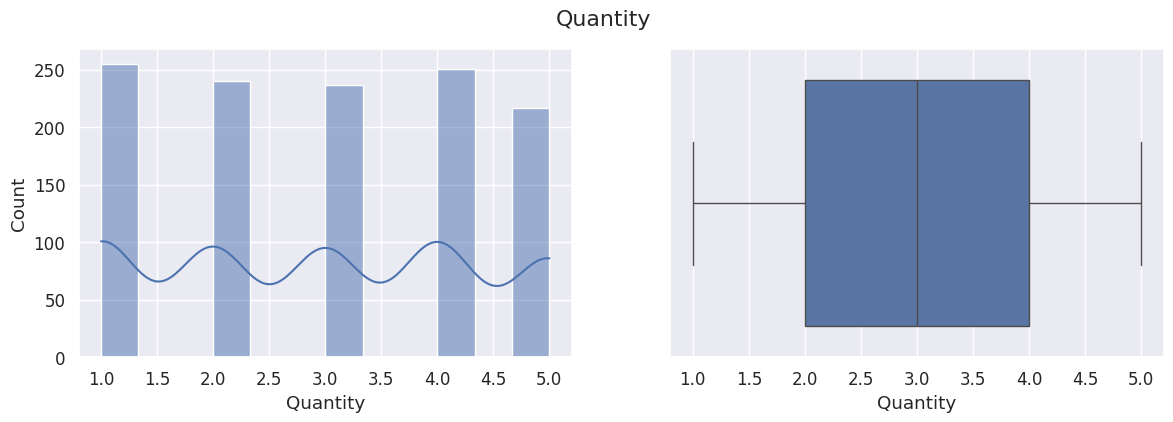

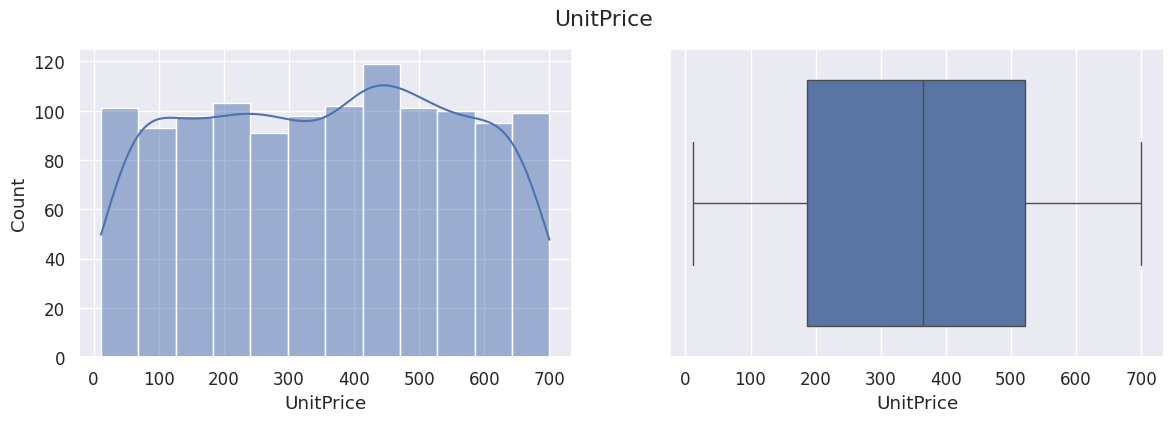

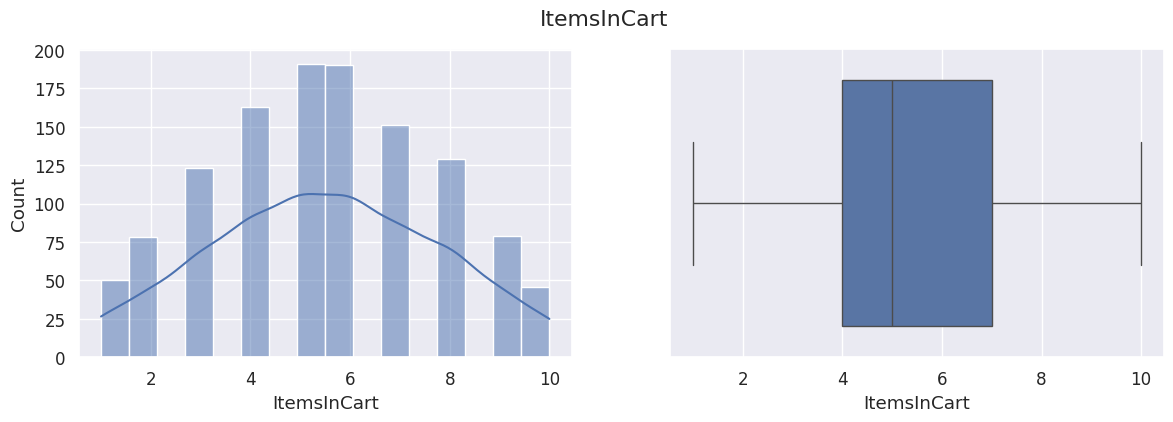

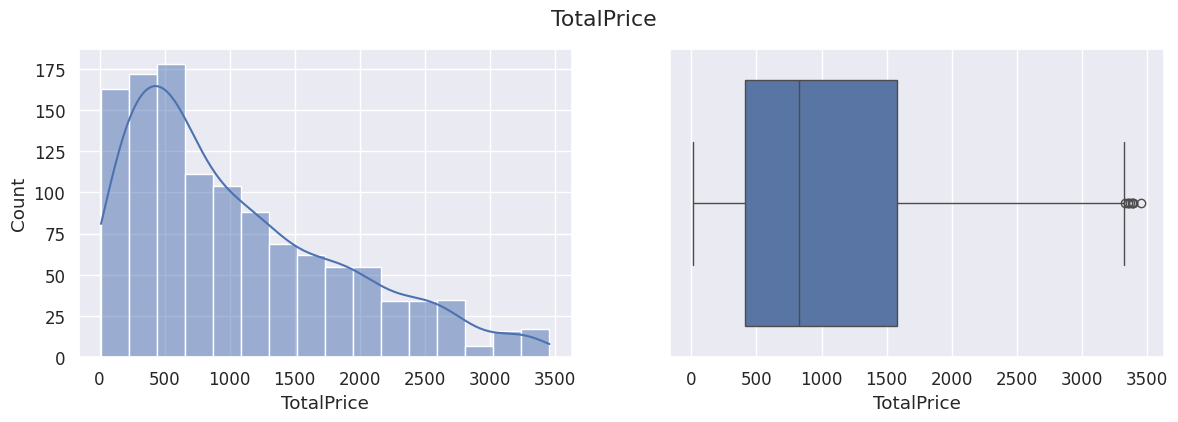

In [14]:
for col in numerical:
  plt.figure(figsize=(14,4))

  plt.subplot(1,2,1)
  sns.histplot(df[col], kde=True)

  plt.subplot(1,2,2)
  sns.boxplot(x=df[col])

  plt.suptitle(col)

  plt.show()

### Categorical Analysis

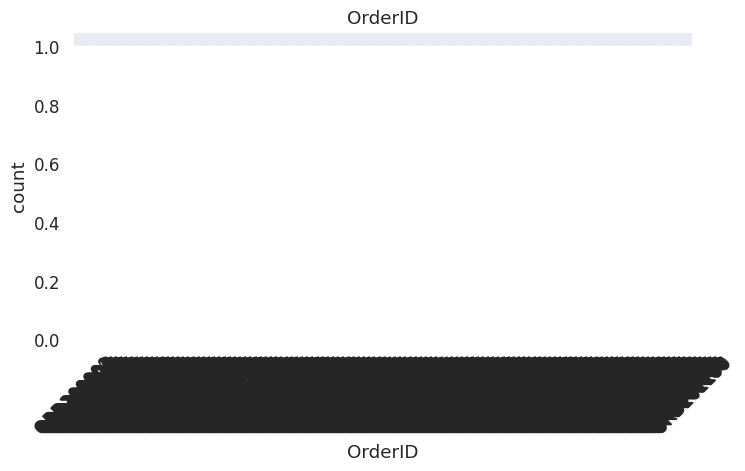

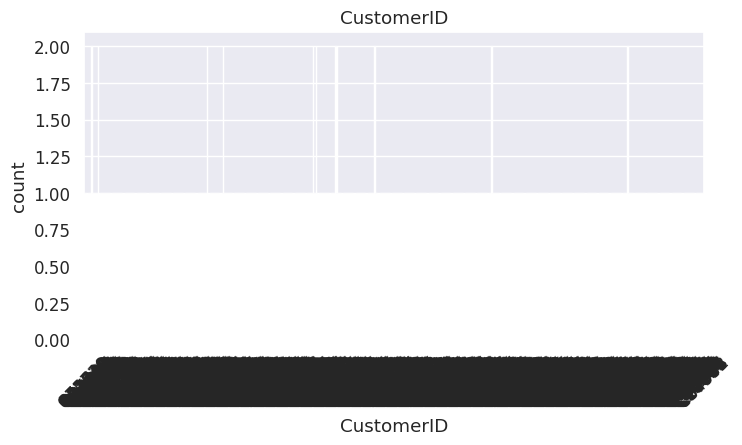

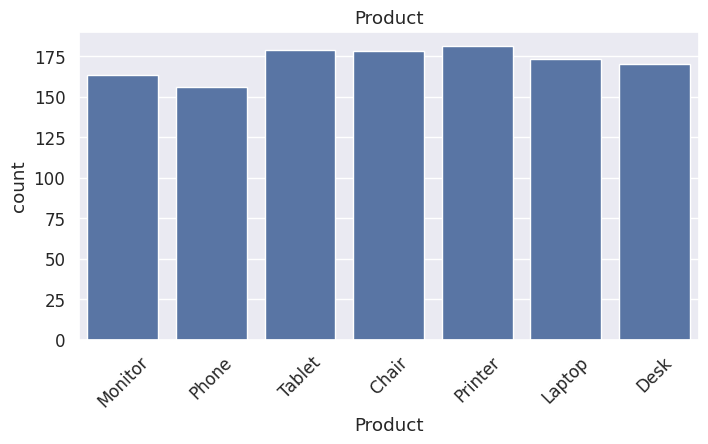

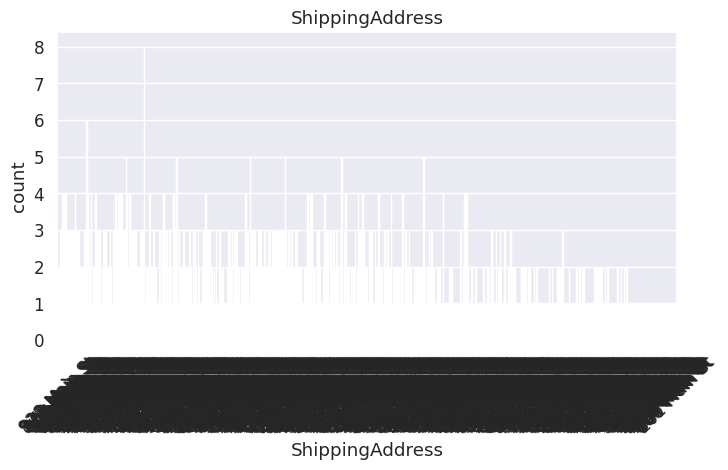

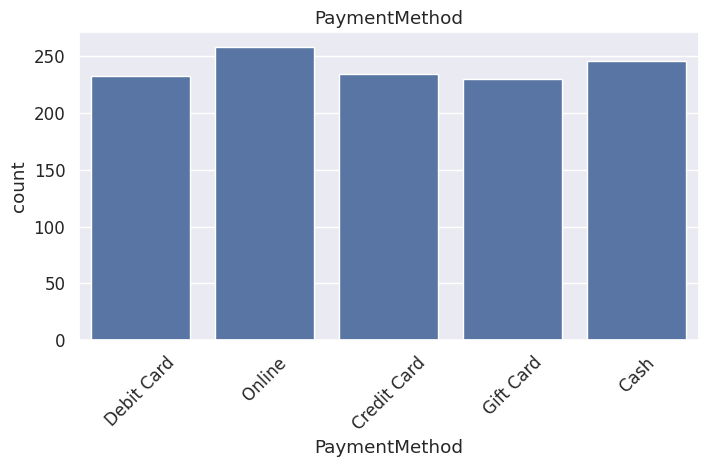

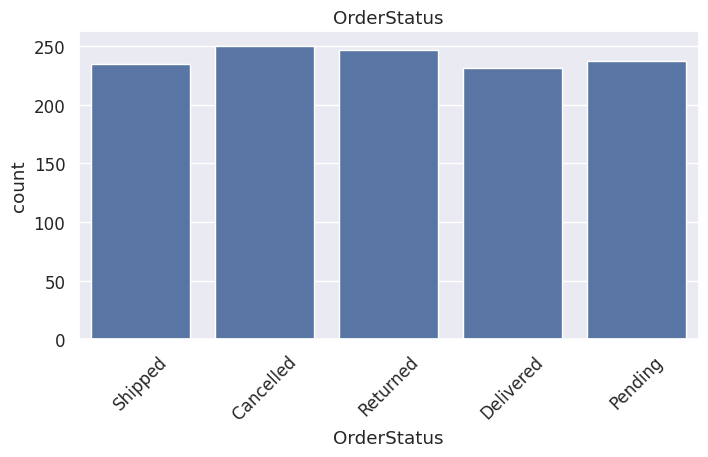

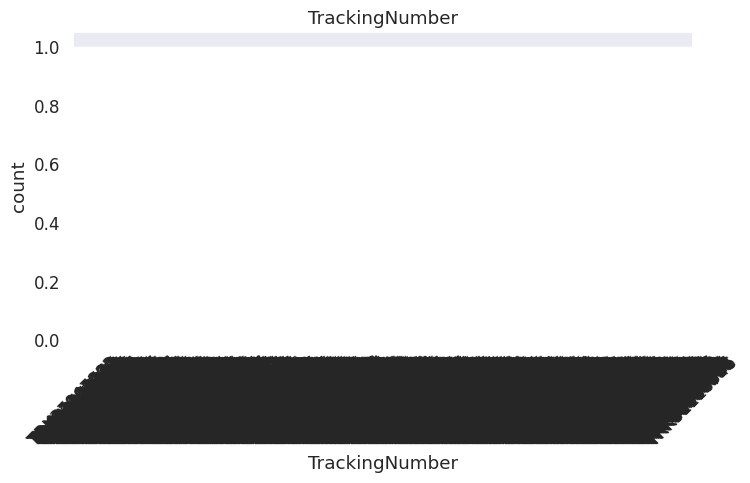

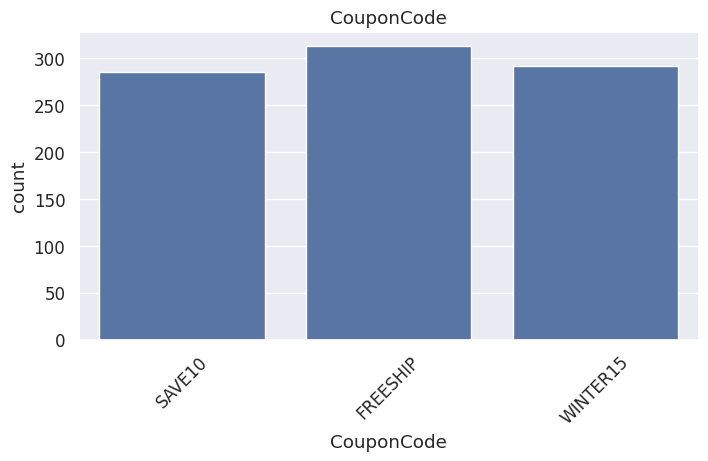

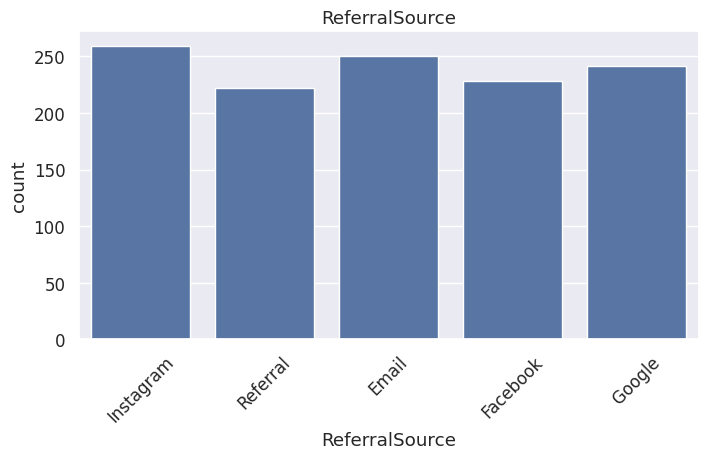

In [15]:
for col in categorical:

  plt.figure(figsize=(8,4))

  sns.countplot(data=df, x=col)

  plt.xticks(rotation=45)

  plt.title(col)

  plt.show()

### Correlation Matrix

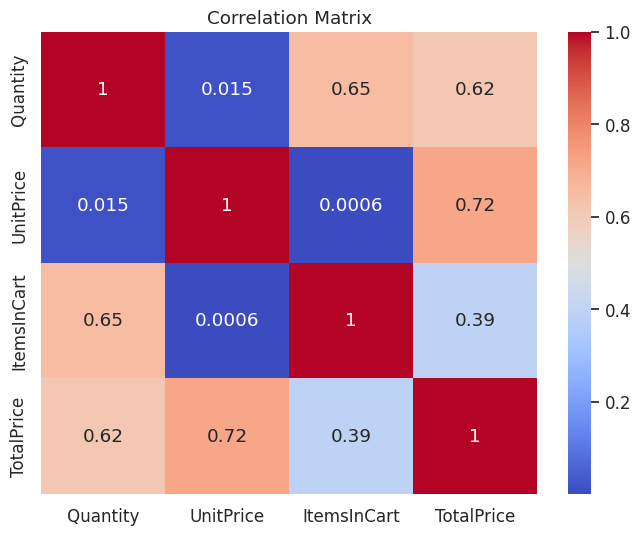

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(df[numerical].corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Missing Value Treatment

In [17]:
df.isnull().sum()

df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


### Demonstrate Mean, Median & KNN Imputation

In [18]:
demo = df.copy()

demo.loc[demo.sample(frac=0.05).index, "Quantity"] = np.nan

# Mean
mean_df = demo.copy()
mean_df["Quantity"] = mean_df["Quantity"].fillna(mean_df["Quantity"].mean())

# Median
median_df = demo.copy()
median_df["Quantity"] = median_df["Quantity"].fillna(median_df["Quantity"].median())

# KNN
knn_df = demo.copy()
imputer = KNNImputer(n_neighbors=5)

knn_df[["Quantity", "unitPrice", "ItemsInCart", "TotalPrice"]] = imputer.fit_transform(
    knn_df[["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]]
)

### Detect Outliers (IQR)

In [19]:
def detect_outliers(data, column):
  Q1 = data[column].quantile(0.25)

  Q3 = data[column].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1-1.5*IQR
  upper = Q3+1.5*IQR

  outliers = data[(data[column]<lower) | (data[column]>upper)]

  print(column)

  print("Outliers :", len(outliers))
  print("-"*40)

for col in numerical:
  detect_outliers(df,col)

Quantity
Outliers : 0
----------------------------------------
UnitPrice
Outliers : 0
----------------------------------------
ItemsInCart
Outliers : 0
----------------------------------------
TotalPrice
Outliers : 8
----------------------------------------


### Winsorization(Cap Outlier)

In [20]:
def winsorize(data, column):
   Q1 = data[column].quantile(0.25)
   Q3 = data[column].quantile(0.75)

   IQR = Q3 - Q1
   lower = Q1-1.5*IQR
   upper = Q3+1.5*IQR

   data[column] = np.where(data[column]>upper,
                           upper,
                           data[column])

   data[column] = np.where(data[column]<lower,
                           lower,
                           data[column])

   return data

for col in numerical:

 df = winsorize(df, col)
 print(df)

        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor       5.0     570.62   
1     ORD200001 2024-08-23     C75739    Phone       2.0     151.35   
2     ORD200002 2024-02-27     C81728   Tablet       5.0     550.68   
3     ORD200003 2023-10-15     C33540    Chair       1.0     273.19   
4     ORD200004 2025-05-08     C81840  Printer       4.0     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk       1.0     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor       2.0     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet       2.0     436.84   
1198  ORD201198 2024-08-22     C64753    Chair       4.0     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet       4.0     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card     Shipped    TRK37947903        

### Feature Engineering

In [21]:
# Month
df["Month"] = df["Date"].dt.month

# Year
df["Year"] = df["Date"].dt.year

# Day
df["Day"] = df["Date"].dt.day

# Day Name
df["DayName"] = df["Date"].dt.day_name()

# Weekend
df["Weekend"] = np.where(df["Date"].dt.dayofweek>=5,1,0)

# Coupon Used
df["CouponUsed"] = np.where(df["CouponCode"] == "No Coupon",0,1)

# Average Price Per Item
df["AveragePrice"] = df["TotalPrice"] / df["Quantity"]

# High Value Order
median = df["TotalPrice"].median()

df["HighValueOrder"] = np.where(df["TotalPrice"]>median,1,0)

# Cart Category
df["CartCategory"] = pd.cut(df["ItemsInCart"],
                            bins=[0,2,5,20],
                            labels=["Small", "Medium", "Large"])

### One Hot Encoding

In [22]:
df = pd.get_dummies(df,
                   columns=["Product",
                            "PaymentMethod",
                            "ReferralSource",
                            "OrderStatus"],
                   drop_first=True)

### Scaling

#### Standard Scaler

In [23]:
scaler = StandardScaler()

scaled = scaler.fit_transform(df[["Quantity",
                                 "UnitPrice",
                                 "ItemsInCart",
                                 "TotalPrice"]])

scaled = pd.DataFrame(scaled,
                      columns=["Quantity",
                               "UnitPrice",
                               "ItemsInCart",
                               "TotalPrice"])

scaled.head()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
0,1.459993,1.086822,0.664173,2.198222
1,-0.672248,-1.040426,-1.089419,-0.917354
2,1.459993,0.985653,1.102571,2.076428
3,-1.382995,-0.422247,-0.212623,-0.953404
4,0.749246,1.367855,1.102571,1.771809


#### MinMax Scaler

In [24]:
minmax = MinMaxScaler()

scaled2 = minmax.fit_transform(df[["Quantity",
                                  "UnitPrice",
                                  "ItemsInCart",
                                  "TotalPrice"]])

scaled2 = pd.DataFrame(scaled2,
                       columns=["Quantity",
                                "UnitPrice",
                                "ItemsInCart",
                                "TotalPrice"])

scaled2.head()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
0,1.00,0.812197,0.666667,0.856190
1,0.25,0.203271,0.222222,0.087770
2,1.00,0.783237,0.777778,0.826151
3,0.00,0.380225,0.444444,0.078879
4,0.75,0.892642,0.777778,0.751020


### Correlation After Feature Engineering

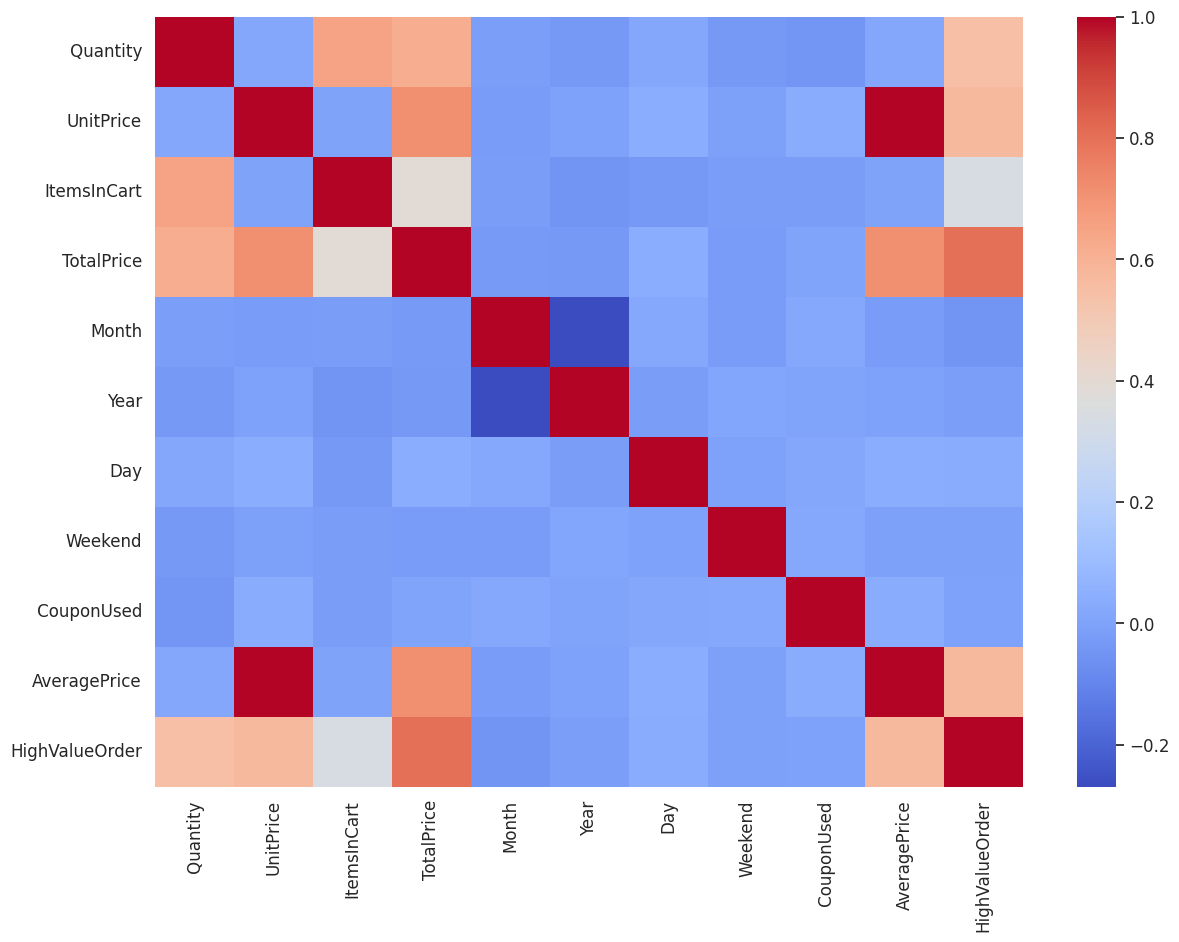

In [25]:
plt.figure(figsize=(14,10))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            cmap="coolwarm")

plt.show()

### Save Clean Dataset

In [26]:
df.to_csv("Cleaned_Dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


### Download Datasets

In [27]:
from google.colab import files
files.download("Cleaned_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>